# Step 4 — SOURCE WINDOW · burst #21 `bn110920546`
**Status: FINALIZED** — approved by VIKAS. Gate: figure PASS-with-nits (round 4).

The window whose spectra we fit. Unchanged by the background rulings — but its *context*
changed, and a long-standing warning on this burst disappeared as a result.

In [1]:
import os, json, glob, hashlib, ast, numpy as np
import astropy.io.fits as fits
from astropy.table import Table
ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", "..", ".."))
BURST = "bn110920546"
sha = lambda p: hashlib.sha256(open(p,"rb").read()).hexdigest()
rel = lambda p: os.path.join(ROOT, p)
appr = json.load(open(rel(f"results/sweep106/{BURST}/APPROVALS.json")))
print("repo:", ROOT, "| burst:", BURST)

repo: /Users/salim/Desktop/Projects/SingleRest/Two_Breaks | burst: bn110920546


In [2]:
STEP = "4"

In [3]:
s = appr[STEP]
print(f'step {STEP}: {s["status"]}  by {s["by"]}  {s["utc"]}')
for f in s.get("feedback", []):
    print(f'\n  PI feedback: {f["text"][:400]}')

step 4: APPROVED  by VIKAS  2026-08-31T20:41:00Z

  PI feedback: LATE-RECORDED STAMP. The PI approved step 4 on 2026-08-31 (option 'Approve step 4'), and the session TOLD him it was approved, but never wrote the stamp — the approval lived only in chat for ~7 h. Caught mechanically 2026-09-01 when the NR-19 cascade found no APPROVED stamp at step 4 to demote. Recorded here with the delay stated rather than back-dated silently. NOT a fabricated approval: the PI's


## 1. The window, and the gap it must sit inside

The common background gap is bounded by the **earliest** post-background across detectors.
b0's old window started at 79.46 s, which is why the source window overran the gap.

In [4]:
cat = Table.read(rel("results/background_intervals.ecsv"), format="ascii.ecsv")
rows = cat[[str(t).strip()==BURST for t in cat["TRIGGER_NAME"]]]
gap_lo = max(float(r["BKG_NEG_STOP"]) for r in rows)
gap_hi = min(float(r["BKG_POS_START"]) for r in rows)
src = (float(rows["SRC_START"][0]), float(rows["SRC_STOP"][0]))
print(f'  source window : {src[0]:.6f} .. {src[1]:.6f} s')
print(f'  common gap    : {gap_lo:.6f} .. {gap_hi:.6f} s   (gap_hi set by {[str(r["DETECTOR"]) for r in rows if abs(float(r["BKG_POS_START"])-gap_hi)<1e-9]})')
print(f'  left margin   : {src[0]-gap_lo:+.4f} s')
print(f'  right margin  : {gap_hi-src[1]:+.4f} s')
print(f'\n  overrun warning fires iff SRC_STOP > gap_hi : {src[1] > gap_hi}')
print("  (it was True before the b0 amendment; the warning is now absent BY DATA)")

  source window : -3.240117 .. 111.303771 s
  common gap    : -5.539562 .. 111.303771 s   (gap_hi set by ['b0'])
  left margin   : +2.2994 s
  right margin  : +0.0000 s

  overrun warning fires iff SRC_STOP > gap_hi : False
  (it was True before the b0 amendment; the warning is now absent BY DATA)


## 2. The zero right margin — a fragility the amendment created

`BKG_POS_START` is now bit-identical to `SRC_STOP`. The overrun guard is a **strict**
inequality, so the exactly-touching case is precisely the one it can never flag.

  bit-identical floats? True  difference: 0.0
  figure sha matches verified artifact? True
  verdict: PASS-WITH-NITS (round 4) — overrun annotation gone, proved by positive control; 1 MUST-FIX (strict-inequality guard at the touching boundary)


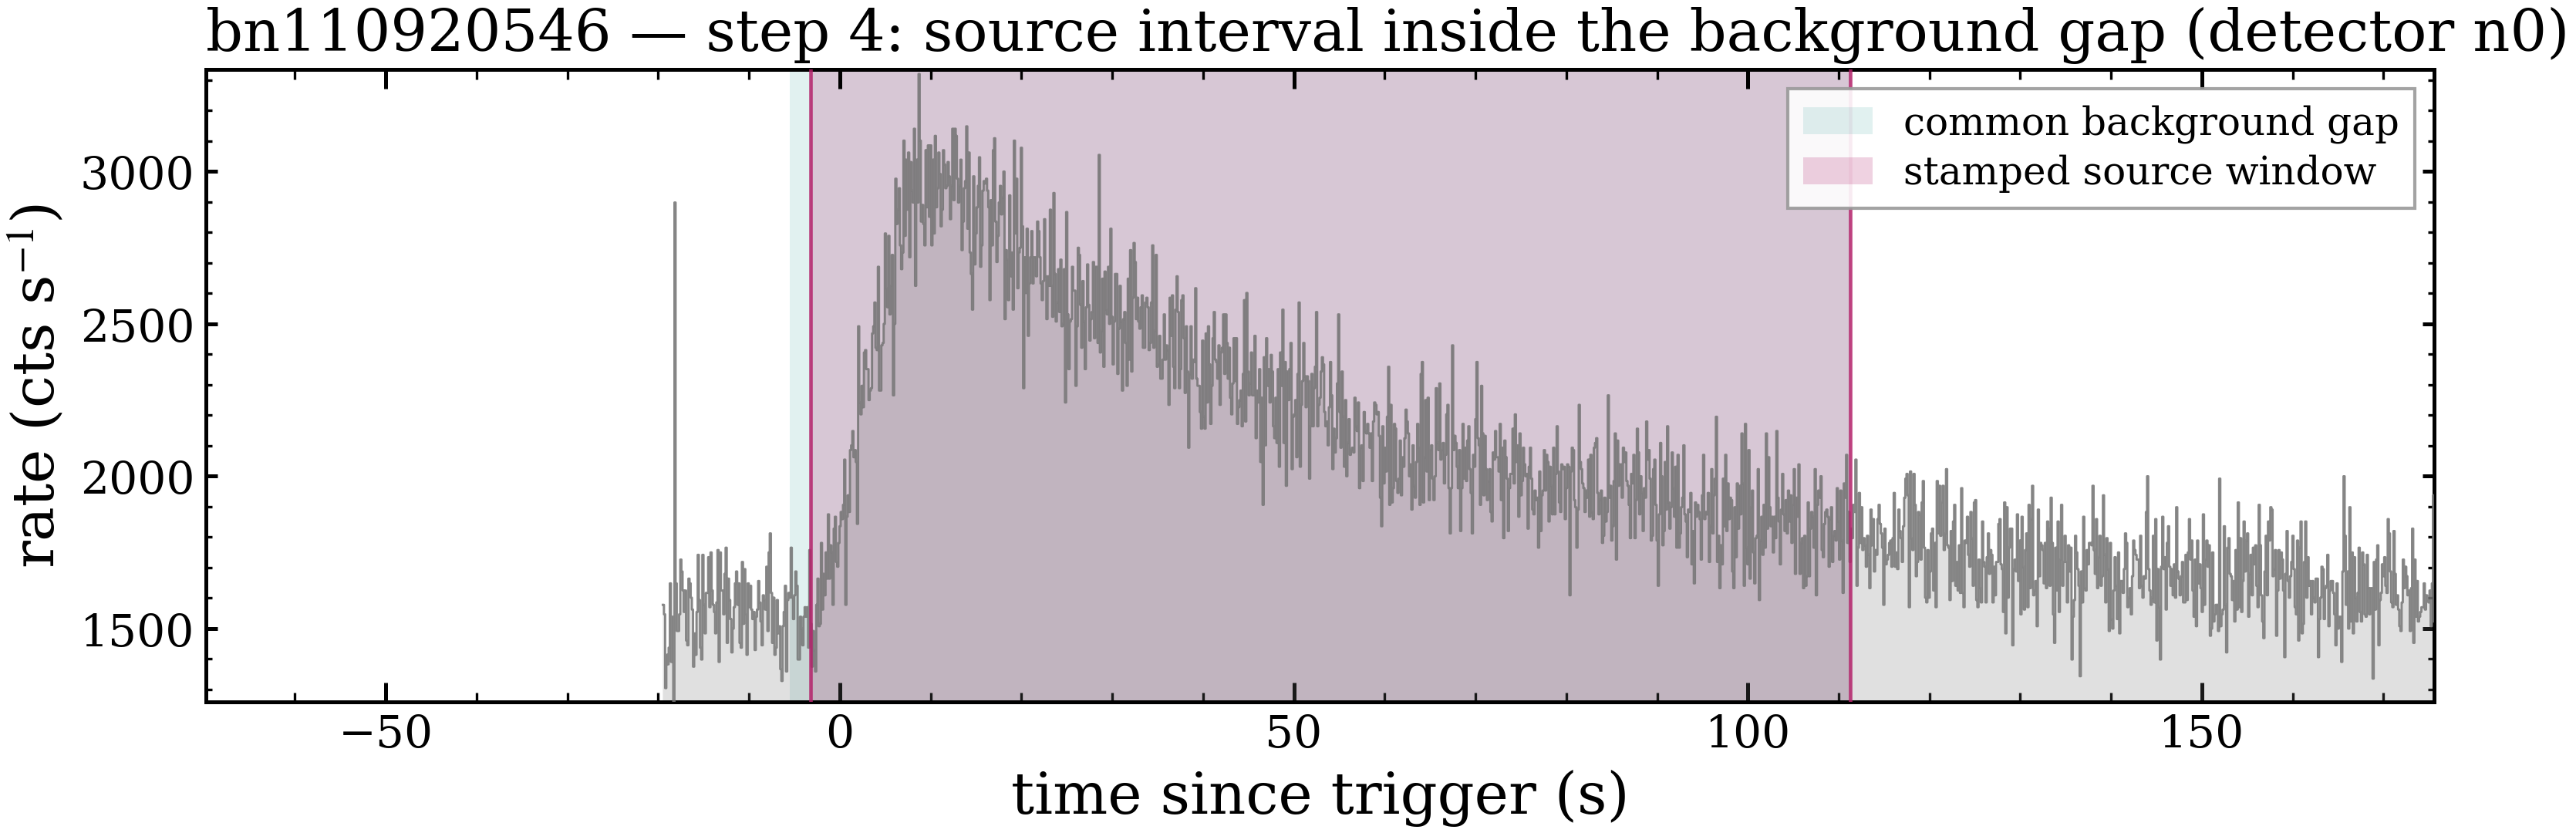

In [5]:
print("  bit-identical floats?", gap_hi == src[1], " difference:", gap_hi - src[1])
fig = rel(f"results/sweep106/{BURST}/{BURST}_step4_source.png")
pin = json.load(open(rel("results/campaign/CAMPAIGN_COMMIT_PIN.json")))["gate_verdicts_hash_bound"]["bn110920546_step4"]
print("  figure sha matches verified artifact?", pin["artifact_sha256"] == sha(fig))
print("  verdict:", pin["verdict"])
from IPython.display import Image, display
display(Image(filename=fig))

## 3. What may NOT be claimed from this panel
Not *"the source window sits safely inside the gap"* — the right margin is zero, the white
region beyond it is **not** background for the detector shown (n0's own background resumes
27 s later), and much of it lies inside the catalogue T90. And not *"there is no precursor"* —
the panel is not a search, and the −18.31 s feature on it is the instrumental stall
(diagnosed in the step-3 notebook), which on this panel reads as a +12σ spike.